# 🧬✨ Radical Prostatectomy Outcomes Study ✨🩺

## Transperineal vs Transrectal Examination Impact

### 📈 Upstage • Upgrade • Downgrade Analysis

---
*Built for robust clinical-statistical exploration using your existing YlivertainenBadDataCraniotomy toolkit* 🚀

---
## **SETUP**
---

In [1]:
#🟧🟧🟧🟧🟧 Modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dda import YlivertainenDDA
from eda import YlivertainenEDA

In [2]:
df = pd.read_excel("RPE 2020-2025.xlsx")
df.columns

Index(['gads', 'Personas kods', 'Vecums', 'PSA līmenis pirms biops',
       'MRI lesions 1 PIRADS', 'MRI lesions 2 PIRADS', 'MRI lesions 3 PIRADS',
       'TNM pirms op.  (MDK slēdziens)',
       'Riska grupa (zema -1; vidēja-2, augsta-3 )', 'gleason grade biopsijā',
       'biospsijas veids', 'RPE grade',
       'Laiks no biopsijas (veikšanas) līdz operācijai ', 'Pvol', 'upgrade',
       'upstage', 'downgrade', 'RPE TNM', 'PSA bīlvums', 'R1?'],
      dtype='str')

In [3]:
df.columns = ['year', 'pk', 'age', 'preop_PSA',
       'lesion_1_MRI_PIRADS', 'lesion_2_MRI_PIRADS', 'lesion_3_MRI_PIRADS',
       'preop_TNM_MDK',
       'risk_group', 'biopsy_gleason_grade',
       'biopsy_type', 'RPE_grade',
       'biopsy_to_RPE_days', 'prostate_volume', 'upgrade',
       'upstage', 'downgrade', 'RPE_TNM', 'PSA_density', 'resection_lines_pos']

df = df.reindex([
    'year', 'biopsy_type',
    'lesion_1_MRI_PIRADS', 'lesion_2_MRI_PIRADS', 'lesion_3_MRI_PIRADS',
    'age', 'preop_PSA', 'preop_TNM_MDK',
    'risk_group', 'biopsy_gleason_grade',
    'RPE_grade',
    'biopsy_to_RPE_days', 'prostate_volume', 'upgrade',
    'upstage', 'downgrade', 'RPE_TNM', 'PSA_density', 'resection_lines_pos', 'pk'], axis=1
)

df.head(2)

,year,biopsy_type,lesion_1_MRI_PIRADS,lesion_2_MRI_PIRADS,lesion_3_MRI_PIRADS,age,preop_PSA,preop_TNM_MDK,risk_group,biopsy_gleason_grade,RPE_grade,biopsy_to_RPE_days,prostate_volume,upgrade,upstage,downgrade,RPE_TNM,PSA_density,resection_lines_pos,pk
0,2020,transrektāla,5,0,0,57,16.2,T2cN0M0,augsta,2,2,194,41.0,0,0,0,T2cN0M0,0.395122,0,280362-12350
1,2020,transrektāla,0,0,0,64,10.4,T2N1M0,augsta,2,2,169,26.2,0,0,0,T2cN0M0,0.396947,0,010855-11322


In [4]:
project = YlivertainenDDA(task="RPE_petijums", df=df)
df = project.DDA

In [5]:
#🟧🟧🟧🟧🟧 int columns
for col in {'year', 'age', 'biopsy_gleason_grade', 'biopsy_to_RPE_days'}:
    df[col] = df[col].astype('int')

#🟧🟧🟧🟧🟧 categorical columns
df.biopsy_type = pd.Categorical(df.biopsy_type, categories=['transrektāla', 'transperineāla'], ordered=False)

df.preop_TNM_MDK = pd.Categorical(df.preop_TNM_MDK, categories=[
    'T2cN0M0',  'T2N1M0', 'T2aN0M0', 'T3bN0M0', 'T3aN0M0',  'T2N0M0', 'T2bN0M0',
    'T1cN0M0',  'T1N0M0',  'T3N0M0',  'T3N1M0', 'T2cN1M0', 'T3bN2M0',  'T2N0Mx',
    'T3bNxM0',  'T2N0M1', 'T1bN0M0'], ordered=False)

df.RPE_TNM = pd.Categorical(df.RPE_TNM, categories=['T2cN0M0', 'T2aN0M0', 'T3bN1M0',  'T2N0M0', 'T2bN0M0', 'T3bN0M0', 'T3aN0M0',
 'T2cN0Mx', 'T2cNxM0', 'T2cN1M0',  'T2NxM0', 'T3aN1M0', 'T1aN0M0', 'T2cNxMx',
  'T2N1M0',  'T3N0M0', 'T3aNxMx', 'T3bNxM0',  'T4N0M0',  'T2NxMx', 'T3aN0Mx',
  'T2N0Mx',  'T2N1Mx', 'T2aNxM0', 'T1cN0M0'], ordered=False)

df.risk_group = pd.Categorical(df.risk_group, categories=['zema', 'vidēja', 'augsta'], ordered=True)

df.biopsy_gleason_grade = pd.Categorical(df.biopsy_gleason_grade.astype('int'), categories=[1,2,3,4,5], ordered=True)

for col in {"lesion_1_MRI_PIRADS"}: df[col] = pd.Categorical(df[col], categories=[0,1,2,3,4,5], ordered=True)

for col in {"RPE_grade", "lesion_2_MRI_PIRADS", "lesion_3_MRI_PIRADS"}:
    df[col] = df[col].replace(0, pd.NA)
    df[col] = pd.Categorical(df[col], categories=[1,2,3,4,5], ordered=True)

#🟧🟧🟧🟧🟧 boolean cols
for col in {'upgrade', 'upstage', 'downgrade', 'resection_lines_pos'}: df[col] = df[col].astype('bool')
project.dataset_overview()

🟧 Rows & columns
  📏 rows:    1180
  📐 columns: 20

🟧 Dtype summary
  🔹 year                 : int64
  🔹 biopsy_type          : category
  🔹 lesion_1_MRI_PIRADS  : category
  🔹 lesion_2_MRI_PIRADS  : category
  🔹 lesion_3_MRI_PIRADS  : category
  🔹 age                  : int64
  🔹 preop_PSA            : float64
  🔹 preop_TNM_MDK        : category
  🔹 risk_group           : category
  🔹 biopsy_gleason_grade : category
  🔹 RPE_grade            : category
  🔹 biopsy_to_RPE_days   : int64
  🔹 prostate_volume      : float64
  🔹 upgrade              : bool
  🔹 upstage              : bool
  🔹 downgrade            : bool
  🔹 RPE_TNM              : category
  🔹 PSA_density          : float64
  🔹 resection_lines_pos  : bool
  🔹 pk                   : str


In [6]:
from cleaning import resolve_dupes

dupes_df = resolve_dupes(df=df, id_cols=['pk', 'year'], include_first=True, drop=False)
#dupes_df.to_csv("RPE_dupes.csv", index=False)


══════════════════════════════════════════════════════════════════════
🔍 DUPE SEARCH 
──────────────────────────────────────────────────────────────────────
✔ Dupe search:
There are 20 rows in duplicate groups based on complete normalized ID: ['pk', 'year']
Note: includes the first row in each duplicate group. Rows with incomplete IDs were ignored


,year,biopsy_type,lesion_1_MRI_PIRADS,lesion_2_MRI_PIRADS,lesion_3_MRI_PIRADS,age,preop_PSA,preop_TNM_MDK,risk_group,biopsy_gleason_grade,RPE_grade,biopsy_to_RPE_days,prostate_volume,upgrade,upstage,downgrade,RPE_TNM,PSA_density,resection_lines_pos,pk
3,2020,transrektāla,5,NaN,NaN,58,11.60,T3bN0M0,augsta,3,5,122,37.00,True,False,False,T3bN1M0,0.313514,False,200861-11455
23,2020,transperineāla,4,4,NaN,71,8.34,T2cN0M0,augsta,2,2,85,24.00,False,False,False,T2cN0M0,0.347500,False,240448-12550
32,2020,transrektāla,5,5,NaN,58,11.60,T3bN0M0,augsta,3,5,162,37.00,True,False,False,T3bN1M0,0.313514,False,200861-11455
57,2020,transrektāla,4,5,NaN,68,18.20,T2bN0M0,vidēja,1,3,75,47.00,True,True,False,T3aN0M0,0.387234,False,240551-12453
71,2020,transrektāla,5,4,NaN,68,18.20,T2bN0M0,augsta,2,3,74,47.00,True,True,False,T3aN0M0,0.387234,False,240551-12453
76,2020,transperineāla,4,4,NaN,71,8.34,T2cN0M0,augsta,2,2,158,24.41,False,False,False,T2cN0Mx,0.341663,False,240448-12550
158,2020,transrektāla,4,3,NaN,64,6.50,T3bN0M0,augsta,1,2,175,32.00,True,False,False,T3aN0M0,0.203125,False,080246-11567
165,2020,transrektāla,4,3,NaN,74,6.50,T3aN0M0,augsta,1,2,182,42.93,True,False,False,T3aN0M0,0.151409,False,080246-11567
227,2021,transrektāla,5,NaN,NaN,65,6.42,T3aN0M0,augsta,4,2,133,26.00,False,True,True,T3bN0M0,0.246923,False,180455-10721
242,2021,transrektāla,5,NaN,NaN,65,6.42,T3aN0M0,augsta,4,4,134,26.00,False,True,False,T3N0M0,0.246923,False,180455-10721


---
# **DDA**
---

In [7]:
from pathlib import Path
import pandas as pd

from dda import YlivertainenDDA
from eda import YlivertainenEDA
from predictive_modeling import build_model_frame
from inferential import YlivertainenInferential

In [8]:
df.columns

Index(['year', 'biopsy_type', 'lesion_1_MRI_PIRADS', 'lesion_2_MRI_PIRADS',
       'lesion_3_MRI_PIRADS', 'age', 'preop_PSA', 'preop_TNM_MDK',
       'risk_group', 'biopsy_gleason_grade', 'RPE_grade', 'biopsy_to_RPE_days',
       'prostate_volume', 'upgrade', 'upstage', 'downgrade', 'RPE_TNM',
       'PSA_density', 'resection_lines_pos', 'pk'],
      dtype='str')

In [9]:
ROOT = Path.cwd()  # if notebook is in dev/, this is fine

TASK_NAME = "RPE_petijums"

TARGET_COLS = ["upgrade", "upstage", "downgrade", "resection_lines_pos"]   # add/remove freely
PREDICTOR_COLS = [
    "biopsy_type",
    "age",
    "preop_PSA",
    "risk_group",
    "biopsy_gleason_grade",
    "biopsy_to_RPE_days",
    "PSA_density",
    "lesion_1_MRI_PIRADS",
    "lesion_2_MRI_PIRADS",
    "lesion_3_MRI_PIRADS"
]

NUMERICAL_CONTINUOUS = [
    "age",
    "preop_PSA",
    "biopsy_to_RPE_days",
    "PSA_density",
]

# optional but recommended
LEAKAGE_VARS = set()
MISSINGNESS_DICT = {}   # e.g. {"somecol_missing": "MNAR"}
REDUNDANCY_PAIRS = None # or DataFrame(var_a, var_b, preferred_keep)

# inferential polarity lock (important)
POSITIVE_CLASS = {
    "upgrade": True,   # or 1, depending your column values
    "upstage": True,
    "downgrade": True,
    "resection_lines_pos": True,}

In [10]:
dda = YlivertainenDDA(task=TASK_NAME, df=df)
dda.keep_from_analysis(cols=["pk"])
dda.dataset_overview()

🚫 Kept from analysis: ['pk']
🟧 Rows & columns
  📏 rows:    1180
  📐 columns: 20

🟧 Dtype summary
  🔹 year                 : int64
  🔹 biopsy_type          : category
  🔹 lesion_1_MRI_PIRADS  : category
  🔹 lesion_2_MRI_PIRADS  : category
  🔹 lesion_3_MRI_PIRADS  : category
  🔹 age                  : int64
  🔹 preop_PSA            : float64
  🔹 preop_TNM_MDK        : category
  🔹 risk_group           : category
  🔹 biopsy_gleason_grade : category
  🔹 RPE_grade            : category
  🔹 biopsy_to_RPE_days   : int64
  🔹 prostate_volume      : float64
  🔹 upgrade              : bool
  🔹 upstage              : bool
  🔹 downgrade            : bool
  🔹 RPE_TNM              : category
  🔹 PSA_density          : float64
  🔹 resection_lines_pos  : bool
  🔹 pk                   : str


🔢 ═══════ NUMERICAL ═══════ 🔢

🟧 year 🟧
  🧮 n: 1180   🔀 unique: 6   ❓ missing: 0.00%
  📉 min: 2020.00   📈 max: 2025.00
  ⚖️  median: 2022.00   📊 mean: 2022.45   ✂️ trimmed: 2022.44
  🏷️  mode: 2022
  📏 IQR: 3.00   5%: 2020.00   95%: 2025.00
  📐 std: 1.71
  🌡️  cv: 0.00 🟢 very stable
  ⚖️  skew: 0.05 symmetrical
  🏔️  kurtosis: -1.20 platykurtic (thin tails)


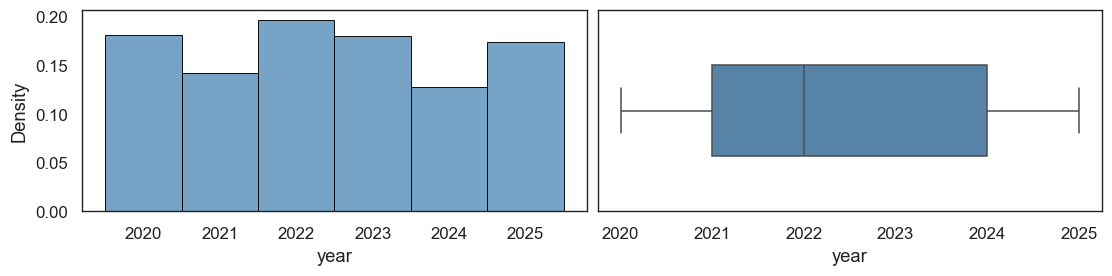


🟧 age 🟧
  🧮 n: 1180   🔀 unique: 38   ❓ missing: 0.00%
  📉 min: 45.00   📈 max: 84.00
  ⚖️  median: 65.00   📊 mean: 64.80   ✂️ trimmed: 65.01
  🏷️  mode: 67
  📏 IQR: 9.00   5%: 53.95   95%: 75.00
  📐 std: 6.50
  🌡️  cv: 0.10 🟢 tight spread
  ↩️  skew: -0.32 left-skewed (most values high)
  ⛰️  kurtosis: -0.13 mesokurtic (normal-ish)


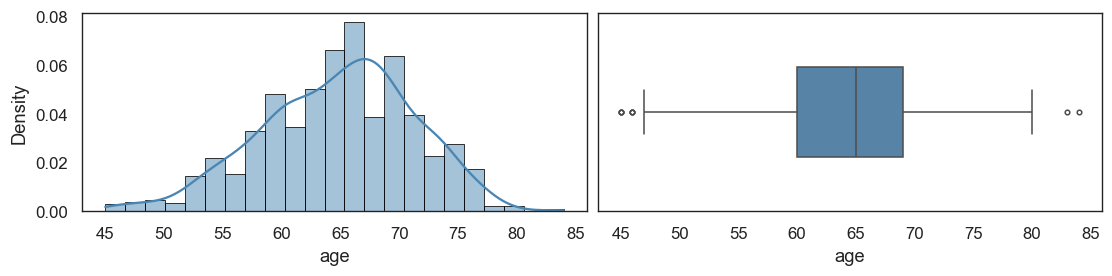


🟧 preop_PSA 🟧
  🧮 n: 1180   🔀 unique: 667   ❓ missing: 0.00%
  📉 min: 0.31   📈 max: 100.00
  ⚖️  median: 8.09   📊 mean: 10.89   ✂️ trimmed: 9.20
  🏷️  mode: 8.00
  📏 IQR: 6.49   5%: 4.11   95%: 26.37
  📐 std: 8.88
  🌡️  cv: 0.81 🟠 noisy
  ↪️  skew: 3.52 right-skewed (most values low)
  🗻  kurtosis: 18.77 leptokurtic (fat tails / outliers)


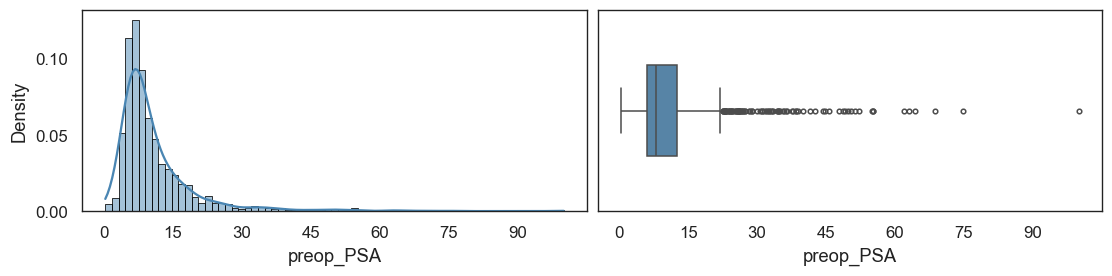


🟧 biopsy_to_RPE_days 🟧
  🧮 n: 1180   🔀 unique: 310   ❓ missing: 0.00%
  📉 min: 0.00   📈 max: 3326.00
  ⚖️  median: 119.00   📊 mean: 173.71   ✂️ trimmed: 129.66
  🏷️  mode: 89, 105
  📏 IQR: 76.00   5%: 62.00   95%: 427.05
  📐 std: 232.79
  🌡️  cv: 1.34 🔴 chaotic
  ↪️  skew: 7.14 right-skewed (most values low)
  🗻  kurtosis: 70.18 leptokurtic (fat tails / outliers)


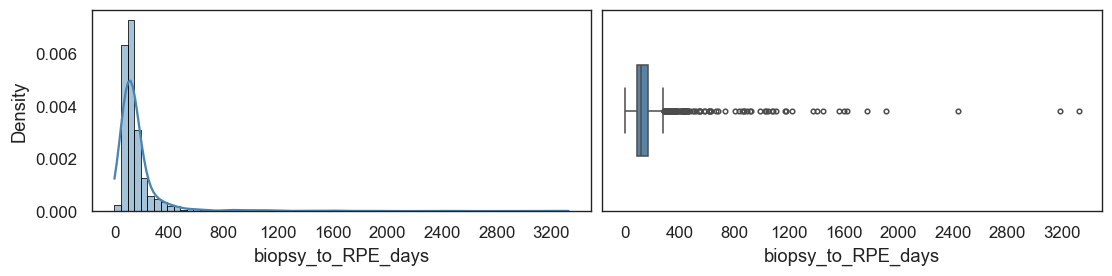


🟧 prostate_volume 🟧
  🧮 n: 1180   🔀 unique: 328   ❓ missing: 0.00%
  📉 min: 2.00   📈 max: 178.00
  ⚖️  median: 39.00   📊 mean: 43.87   ✂️ trimmed: 41.04
  🏷️  mode: 40.00
  📏 IQR: 22.00   5%: 20.00   95%: 85.00
  📐 std: 20.83
  🌡️  cv: 0.47 🟡 moderate
  ↪️  skew: 1.72 right-skewed (most values low)
  🗻  kurtosis: 4.55 leptokurtic (fat tails / outliers)


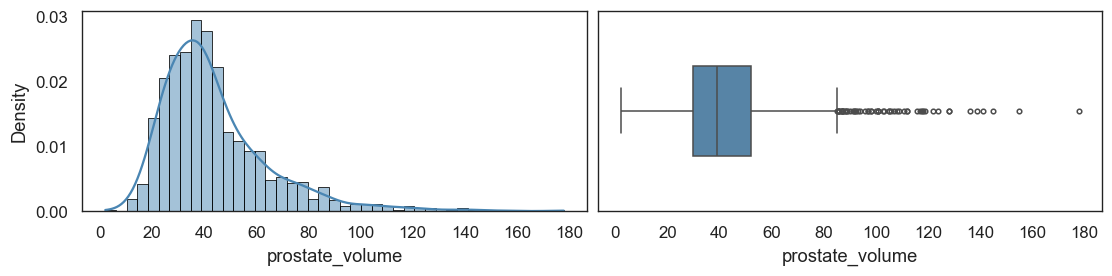


🟧 PSA_density 🟧
  🧮 n: 1180   🔀 unique: 1125   ❓ missing: 0.00%
  📉 min: 0.02   📈 max: 4.55
  ⚖️  median: 0.21   📊 mean: 0.29   ✂️ trimmed: 0.24
  🏷️  mode: 0.20, 0.25
  📏 IQR: 0.20   5%: 0.08   95%: 0.79
  📐 std: 0.30
  🌡️  cv: 1.03 🔴 chaotic
  ↪️  skew: 5.83 right-skewed (most values low)
  🗻  kurtosis: 58.94 leptokurtic (fat tails / outliers)


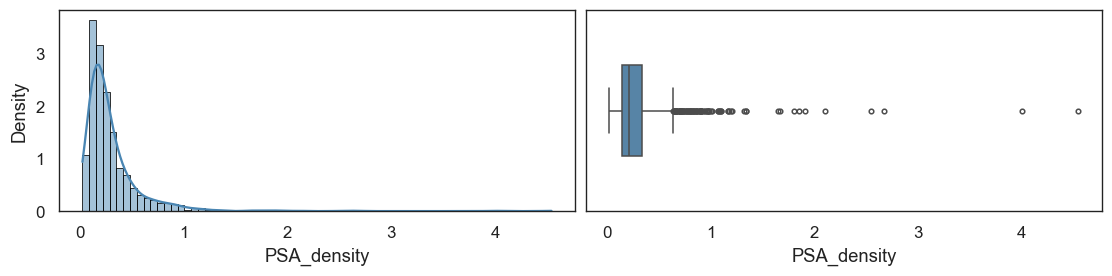


📋 Numerical overview table


,column,n,n_unique,missing_%,min,max,median,mean,trimmed_mean,mode,std,cv,iqr,p_5th,p_95th,skewness,kurtosis
0,year,1180,6,0.00,2020.00,2025.00,2022.00,2022.45,2022.44,2022,1.71,0.00,3.00,2020.00,2025.00,0.05,-1.20
1,age,1180,38,0.00,45.00,84.00,65.00,64.80,65.01,67,6.50,0.10,9.00,53.95,75.00,-0.32,-0.13
2,preop_PSA,1180,667,0.00,0.31,100.00,8.09,10.89,9.20,8.00,8.88,0.81,6.49,4.11,26.37,3.52,18.77
3,biopsy_to_RPE_days,1180,310,0.00,0.00,3326.00,119.00,173.71,129.66,"89, 105",232.79,1.34,76.00,62.00,427.05,7.14,70.18
4,prostate_volume,1180,328,0.00,2.00,178.00,39.00,43.87,41.04,40.00,20.83,0.47,22.00,20.00,85.00,1.72,4.55
5,PSA_density,1180,1125,0.00,0.02,4.55,0.21,0.29,0.24,"0.20, 0.25",0.30,1.03,0.20,0.08,0.79,5.83,58.94


🚦 ═══════ CATEGORICAL ═══════ 🚦

🟧 lesion_1_MRI_PIRADS 🟧
  🧮 n: 1180   ❓ missing: 0.00%
  🔢 cardinality: 5 🟢 very low → one-hot ready
  🏆 mode: 5 (45.1%)
  🥈 second: 4 (42.6%)
  🐭 rarest: 1: 0.00%
  ⚖️  imbalance: 1.06 🟢 balanced
  🎲 entropy: 1.58 🟢 sweet spot
  🪶 balance: 0.68 🟢 healthy


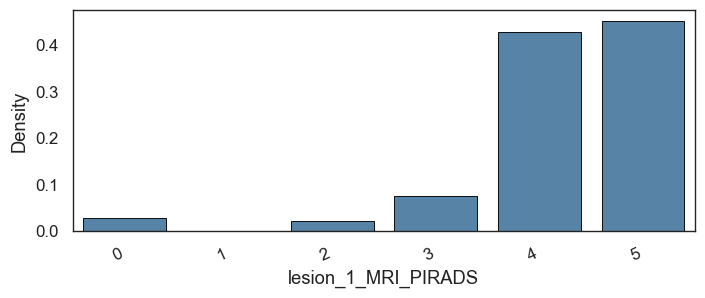


🟧 lesion_2_MRI_PIRADS 🟧
  🧮 n: 293   ❓ missing: 75.17%
  🔢 cardinality: 4 🟢 very low → one-hot ready
  🏆 mode: 4 (60.4%)
  🥈 second: 3 (25.3%)
  🐭 rarest: 1: 0.00%
  ⚖️  imbalance: 2.39 🟢 mild
  🎲 entropy: 1.47 🟠 low diversity
  🪶 balance: 0.74 🟠 broad


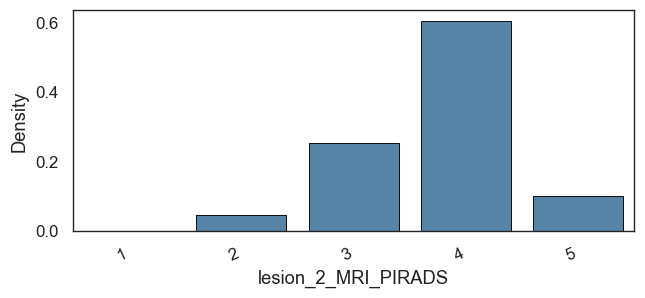


🟧 lesion_3_MRI_PIRADS 🟧
  🧮 n: 35   ❓ missing: 97.03%
  🔢 cardinality: 4 🟢 very low → one-hot ready
  🏆 mode: 3 (45.7%)
  🥈 second: 4 (37.1%)
  🐭 rarest: 1: 0.00%
  ⚖️  imbalance: 1.23 🟢 balanced
  🎲 entropy: 1.64 🟢 sweet spot
  🪶 balance: 0.82 🟠 broad


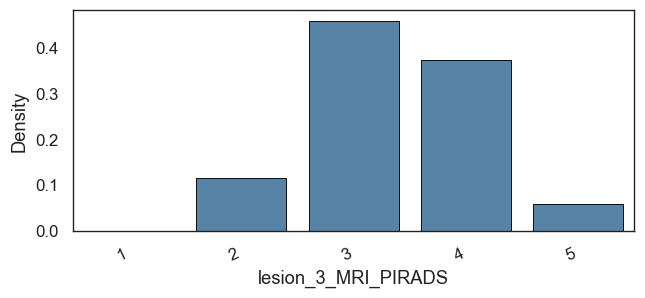


🟧 preop_TNM_MDK 🟧
  🧮 n: 1180   ❓ missing: 0.00%
  🔢 cardinality: 17 🟢 moderate
  🏆 mode: T2cN0M0 (34.4%)
  🥈 second: T2N0M0 (23.1%)
  🐭 rarest: T2N0M1: 0.08%
  ⚖️  imbalance: 1.49 🟢 balanced
  🎲 entropy: 2.72 🟢 sweet spot
  🪶 balance: 0.66 🟢 healthy


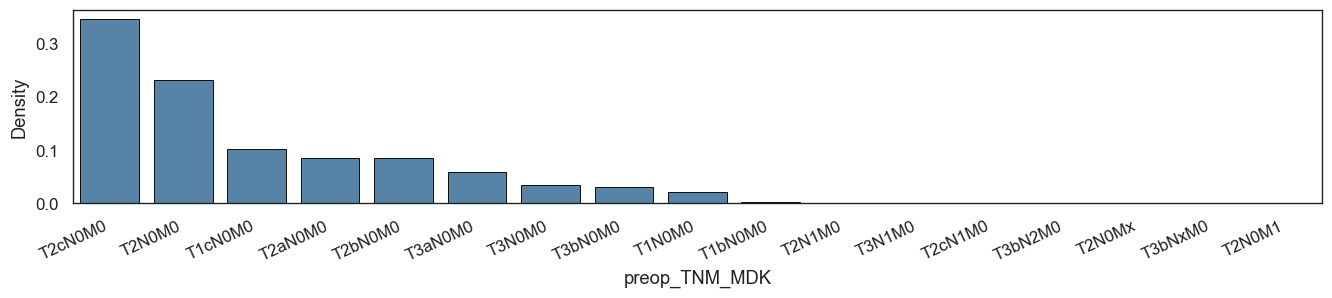


🟧 risk_group 🟧
  🧮 n: 1180   ❓ missing: 0.00%
  🔢 cardinality: 3 🟢 very low → one-hot ready
  🏆 mode: vidēja (45.2%)
  🥈 second: augsta (36.4%)
  🐭 rarest: zema: 18.47%
  ⚖️  imbalance: 1.24 🟢 balanced
  🎲 entropy: 1.50 🟠 low diversity
  🪶 balance: 0.95 🟠 near-uniform


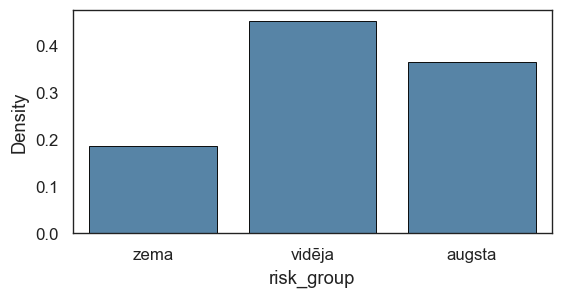


🟧 biopsy_gleason_grade 🟧
  🧮 n: 1180   ❓ missing: 0.00%
  🔢 cardinality: 5 🟢 very low → one-hot ready
  🏆 mode: 2 (42.5%)
  🥈 second: 1 (37.2%)
  🐭 rarest: 5: 2.88%
  ⚖️  imbalance: 1.14 🟢 balanced
  🎲 entropy: 1.80 🟢 sweet spot
  🪶 balance: 0.78 🟠 broad


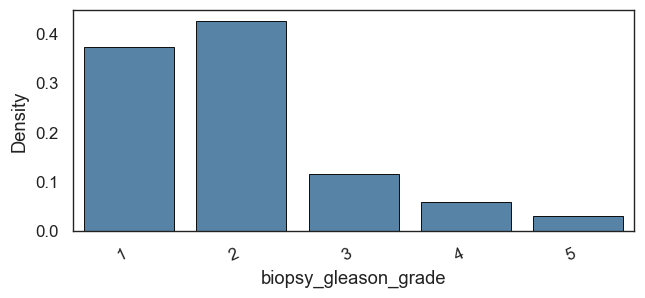


🟧 RPE_grade 🟧
  🧮 n: 1180   ❓ missing: 0.00%
  🔢 cardinality: 5 🟢 very low → one-hot ready
  🏆 mode: 2 (59.5%)
  🥈 second: 1 (15.8%)
  🐭 rarest: 4: 3.56%
  ⚖️  imbalance: 3.77 🟠 strong
  🎲 entropy: 1.69 🟢 sweet spot
  🪶 balance: 0.73 🟠 broad


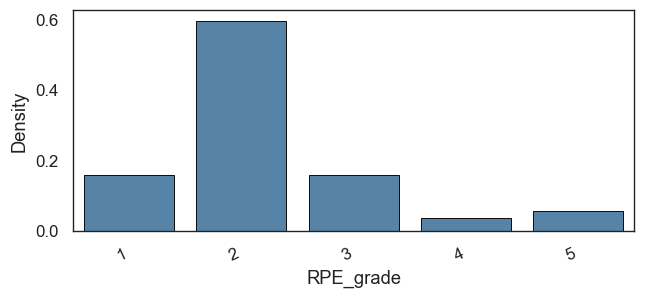


🟧 RPE_TNM 🟧
  🧮 n: 1180   ❓ missing: 0.00%
  🔢 cardinality: 25 🟠 high → group rare levels
  🏆 mode: T3aN0M0 (31.4%)
  🥈 second: T2cN0M0 (24.2%)
  🐭 rarest: T2aNxM0: 0.08%
  ⚖️  imbalance: 1.30 🟢 balanced
  🎲 entropy: 2.70 🟢 sweet spot
  🪶 balance: 0.58 🟢 healthy


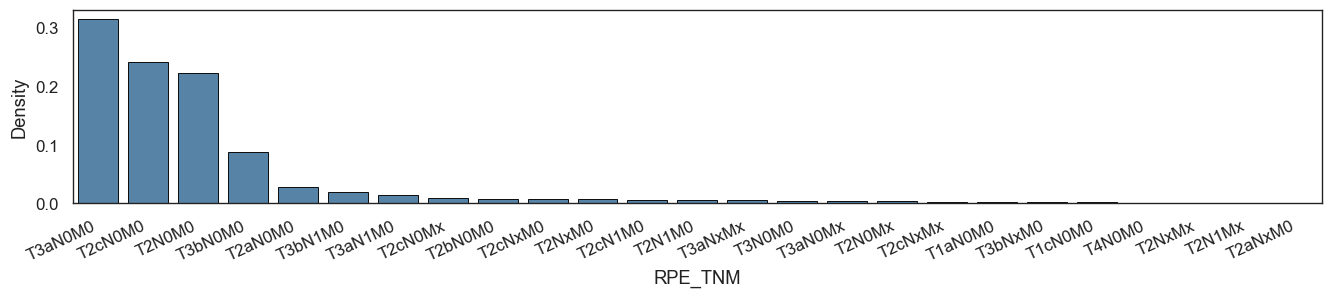


📋 Categorical overview table


,column,n,n_unique,missing_pct,first_mode,second_mode,rarest,first_mode_pct,second_mode_pct,max_class_imbalance,median_category,balance,entropy_bin
0,lesion_1_MRI_PIRADS,1180,5,0.00,5,4,1: 0.00%,45.08,42.63,1.06,4,0.68,1.58
1,lesion_2_MRI_PIRADS,293,4,75.17,4,3,1: 0.00%,60.41,25.26,2.39,4,0.74,1.47
2,lesion_3_MRI_PIRADS,35,4,97.03,3,4,1: 0.00%,45.71,37.14,1.23,3,0.82,1.64
3,preop_TNM_MDK,1180,17,0.00,T2cN0M0,T2N0M0,T2N0M1: 0.08%,34.41,23.05,1.49,,0.66,2.72
4,risk_group,1180,3,0.00,vidēja,augsta,zema: 18.47%,45.17,36.36,1.24,vidēja,0.95,1.50
5,biopsy_gleason_grade,1180,5,0.00,2,1,5: 2.88%,42.54,37.20,1.14,2,0.78,1.80
6,RPE_grade,1180,5,0.00,2,1,4: 3.56%,59.49,15.76,3.77,2,0.73,1.69
7,RPE_TNM,1180,25,0.00,T3aN0M0,T2cN0M0,T2aNxM0: 0.08%,31.36,24.15,1.30,,0.58,2.70


⚖️  ═══════ BINARY ═══════ ⚖️

🟧 biopsy_type 🟧
  🧮 n: 1180   ❓ missing: 0.00%
  🅰️  transrektāla: 0.64    🅱️  transperineāla: 0.36
  🏆 mode: transrektāla (64.1%)
  🪶 balance: 0.72 🟢 healthy
  🎲 entropy: 0.94 🟢 ~50/50, ideal


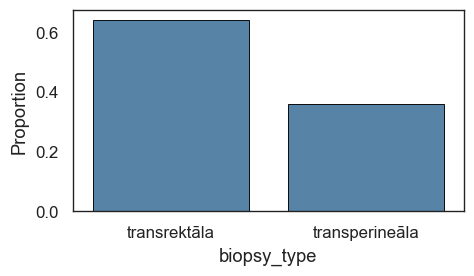


🟧 upgrade 🟧
  🧮 n: 1180   ❓ missing: 0.00%
  🅰️  False: 0.64    🅱️  True: 0.36
  🏆 mode: False (64.4%)
  🪶 balance: 0.71 🟢 healthy
  🎲 entropy: 0.94 🟢 ~50/50, ideal


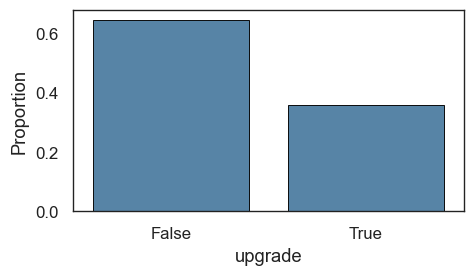


🟧 upstage 🟧
  🧮 n: 1180   ❓ missing: 0.00%
  🅰️  False: 0.56    🅱️  True: 0.44
  🏆 mode: False (55.5%)
  🪶 balance: 0.89 🟢 healthy
  🎲 entropy: 0.99 🟢 ~50/50, ideal


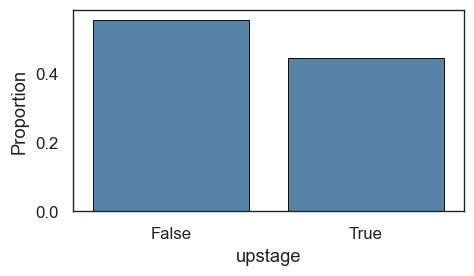


🟧 downgrade 🟧
  🧮 n: 1180   ❓ missing: 0.00%
  🅰️  False: 0.88    🅱️  True: 0.12
  🏆 mode: False (87.9%)
  🪶 balance: 0.24 🟡 heavy imbalance
  🎲 entropy: 0.53 🟡 moderate


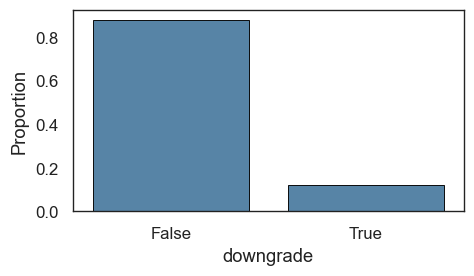


🟧 resection_lines_pos 🟧
  🧮 n: 1180   ❓ missing: 0.00%
  🅰️  False: 0.93    🅱️  True: 0.07
  🏆 mode: False (93.5%)
  🪶 balance: 0.13 🟡 heavy imbalance
  🎲 entropy: 0.35 🟡 moderate


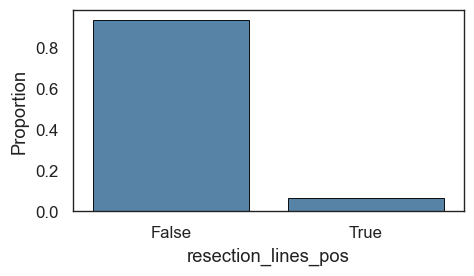


📋 Binary overview table


,column,n,missing_pct,cat1,p1,cat0,p0,mode,mode_pct,balance,entropy_bin
0,biopsy_type,1180,0.00,transrektāla,0.64,transperineāla,0.36,transrektāla,64.07,0.72,0.94
1,upgrade,1180,0.00,False,0.64,True,0.36,False,64.41,0.71,0.94
2,upstage,1180,0.00,False,0.56,True,0.44,False,55.51,0.89,0.99
3,downgrade,1180,0.00,False,0.88,True,0.12,False,87.88,0.24,0.53
4,resection_lines_pos,1180,0.00,False,0.93,True,0.07,False,93.47,0.13,0.35


In [11]:
dda.analyse_numerical().analyse_categorical().analyse_binary()

---
# **EDA**
---

In [ ]:
eda = YlivertainenEDA(df=df, task_name=TASK_NAME)

# set all targets once
eda.target_cols = TARGET_COLS

# whitelist predictors + define continuous numeric subset
eda.whitelist_columns(
    predictors=PREDICTOR_COLS,
    numerical_continuous=NUMERICAL_CONTINUOUS,
)

# target x predictor association table
associations_table = eda.build_associations_table(
    target_cols=TARGET_COLS,
    leakage_vars=LEAKAGE_VARS,
    fdr_alpha=0.05,
    clinical_effect_floor=0.30,
)

# governance table for missingness/drop/imputation decisions
feature_decisions_df = eda.build_feature_decisions_table(
    missingness_dict=MISSINGNESS_DICT,
    leakage_vars=LEAKAGE_VARS,
    redundancy_pairs=REDUNDANCY_PAIRS,
)

# optional export to reports/tables
eda.export_both_tables(export=True)

associations_table[associations_table.fdr_significant == True]

✅ Predictors classified: 10


,column_name,role,dtype,inferred_type,missing_pct,drop_reason,action,missing_action,notes
0,upgrade,target,bool,unknown,0.0,,keep,no_missing,<NA>
1,upstage,target,bool,unknown,0.0,,keep,no_missing,<NA>
2,downgrade,target,bool,unknown,0.0,,keep,no_missing,<NA>
3,resection_lines_pos,target,bool,unknown,0.0,,keep,no_missing,<NA>
4,age,predictor,int64,continuous,0.0,,keep,no_missing,<NA>
5,preop_PSA,predictor,float64,continuous,0.0,,keep,no_missing,<NA>
6,biopsy_to_RPE_days,predictor,int64,continuous,0.0,,keep,no_missing,<NA>
7,PSA_density,predictor,float64,continuous,0.0,,keep,no_missing,<NA>
8,biopsy_type,predictor,category,categorical_nominal,0.0,,keep,no_missing,<NA>
9,risk_group,predictor,category,categorical_ordinal,0.0,,keep,no_missing,<NA>


Saved: reports/tables/(EDA_associations_table)RPE_petijums.xlsx
Saved: reports/tables/(EDA_feature_decisions_table)RPE_petijums.xlsx


,target,predictor,test_name,test_stat,effect_metric,effect_value,ci_low,ci_high,p_value,p_value_fdr,n,missing_pct,status,skipped_reason,fdr_significant,clinically_relevant
1,upgrade,preop_PSA,point_biserial,0.109744,r,0.109744,<NA>,<NA>,0.000159,0.000529,1180,0.0,ok,<NA>,True,False
2,upgrade,biopsy_to_RPE_days,point_biserial,0.084068,r,0.084068,<NA>,<NA>,0.003854,0.009634,1180,0.0,ok,<NA>,True,False
3,upgrade,PSA_density,point_biserial,0.069121,r,0.069121,<NA>,<NA>,0.017562,0.02927,1180,0.0,ok,<NA>,True,False
4,upgrade,biopsy_type,chi2,6.692757,cramers_v,0.075312,<NA>,<NA>,0.009681,0.019361,1180,0.0,ok,<NA>,True,False
5,upgrade,risk_group,chi2,68.578384,cramers_v,0.241075,<NA>,<NA>,0.0,0.0,1180,0.0,ok,<NA>,True,False
6,upgrade,biopsy_gleason_grade,chi2,299.234306,cramers_v,0.503576,<NA>,<NA>,0.0,0.0,1180,0.0,ok,<NA>,True,True
14,upstage,biopsy_type,chi2,16.091086,cramers_v,0.116775,<NA>,<NA>,0.00006,0.000302,1180,0.0,ok,<NA>,True,False
15,upstage,risk_group,chi2,24.424565,cramers_v,0.143871,<NA>,<NA>,0.000005,0.00005,1180,0.0,ok,<NA>,True,False
25,downgrade,risk_group,chi2,51.022616,cramers_v,0.207941,<NA>,<NA>,0.0,0.0,1180,0.0,ok,<NA>,True,False
26,downgrade,biopsy_gleason_grade,chi2,306.49292,cramers_v,0.509647,<NA>,<NA>,0.0,0.0,1180,0.0,ok,<NA>,True,True


In [10]:
project.target_cols = ["upgrade", "upstage", "downgrade"]
#"upstage", "downgrade", "resection_lines_pos"

project.whitelist_columns(
    predictors=["biopsy_type"],
    numerical_continuous=["PSA_density", "age", "prostate_volume", "biopsy_to_RPE_days", "preop_PSA", "age"]
)

project.build_associations_table()

✅ Predictors classified: 1


,target,predictor,test_name,test_stat,effect_metric,effect_value,ci_low,ci_high,p_value,p_value_fdr,n,missing_pct,status,skipped_reason,fdr_significant,clinically_relevant
0,upgrade,biopsy_type,chi2,6.692757,cramers_v,0.075312,<NA>,<NA>,0.009681,0.009681,1180,0.0,ok,<NA>,True,False
1,upstage,biopsy_type,chi2,16.091086,cramers_v,0.116775,<NA>,<NA>,0.00006,0.00006,1180,0.0,ok,<NA>,True,False
2,downgrade,biopsy_type,chi2,0.335817,cramers_v,0.01687,<NA>,<NA>,0.562254,0.562254,1180,0.0,ok,<NA>,False,False


In [11]:
feature_decisions = project.build_feature_decisions_table()

,column_name,role,dtype,inferred_type,missing_pct,drop_reason,action,missing_action,notes
0,upgrade,target,bool,unknown,0.0,,keep,no_missing,<NA>
1,upstage,target,bool,unknown,0.0,,keep,no_missing,<NA>
2,downgrade,target,bool,unknown,0.0,,keep,no_missing,<NA>
3,biopsy_type,predictor,category,categorical_nominal,0.0,,keep,no_missing,<NA>


In [12]:
from inferential import YlivertainenInferential

In [ ]:
project = YlivertainenInferential()



TypeError: YlivertainenInferential.__init__() missing 3 required positional arguments: 'root', 'df_model', and 'feature_decisions_df'